# BIS Central Bank Speeches — Data Analysis and Preprocessing

**Project topic.** Central Bank Communication as Alternative Data: Topic Modeling and Hawkish/Dovish Tone Analysis of BIS Speeches.

This notebook is the first step of the project. Its objective is not to train NLP models yet, but to understand and prepare the dataset properly. Since the final project is evaluated partly on the relevance of the data analysis, I first inspect the structure of the corpus, the available metadata, the temporal coverage, the distribution of speech lengths, and potential data quality issues such as missing values, duplicates, and very short documents.

The output of this notebook is a clean dataset that will be reused in the next notebooks for:

1. TF-IDF + NMF topic modeling;
2. LDA topic modeling;
3. BERTopic;
4. hawkish/dovish tone analysis.

## 1. Environment setup


In [ ]:
import os
import re
import json
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# pd.set_option("display.max_columns", 100)
# pd.set_option("display.max_colwidth", 250)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Project folders

I create a simple folder structure to keep the project reproducible. The cleaned dataset, tables, and figures are saved automatically.

In [ ]:
PROJECT_DIR = "central_bank_nlp"

DIRS = [
    PROJECT_DIR,
    f"{PROJECT_DIR}/data",
    f"{PROJECT_DIR}/data/raw",
    f"{PROJECT_DIR}/data/processed",
    f"{PROJECT_DIR}/figures",
    f"{PROJECT_DIR}/tables",
]

for directory in DIRS:
    os.makedirs(directory, exist_ok=True)

print(f"Project directory created at: {PROJECT_DIR}/")

Project directory created at: central_bank_nlp/


## 3. Loading the BIS speeches dataset

The dataset used in this project is `samchain/bis_central_bank_speeches`, available on Hugging Face. Each observation should correspond to a central bank speech. Before making any modeling decision, I inspect the dataset structure and the available splits.

In [ ]:
dataset = load_dataset("samchain/bis_central_bank_speeches")
dataset

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/179M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19376 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['description', 'text', 'bank', 'Year', 'Month'],
        num_rows: 19376
    })
})

In [ ]:
print("Available splits:", list(dataset.keys()))

split_name = list(dataset.keys())[0]
print("Using split:", split_name)

df = dataset[split_name].to_pandas()

print("DataFrame shape:", df.shape)
df.head()

#all the dataset is contained in "train" with 19k rows

Available splits: ['train']
Using split: train
DataFrame shape: (19376, 5)


,description,text,bank,Year,Month
0,Lecture delivered in honour of Professor Xenop...,Mr. Tietmeyer considers European monetary inte...,bank of greece,1997,10
1,"Speech given by Mr Nicholas C Garganas, Deputy...",Mr Garganas gives a speech on integrating Gree...,bank of greece,1999,9
2,"Address by Mr Nicholas C Garganas, Deputy Gove...",None,bank of greece,2000,3
3,"Speech by Mr Lucas Papademos, Governor of the ...",Lucas Papademos: The completion of the changeo...,bank of greece,2001,10
4,"Address by Mr Nicholas C Garganas, Deputy Gove...",Nicholas Garganas: The Greek economy within th...,bank of greece,2002,5


## 4. Inspecting the raw columns

The first important step is to identify the columns containing the speech text, the date, the title, and possibly the speaker or institution. I do this programmatically first, then I manually verify the result.

In [ ]:
print("Columns:")
for i, col in enumerate(df.columns):
    print(f"{i:02d}. {col}")

Columns:
00. description
01. text
02. bank
03. Year
04. Month


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19376 entries, 0 to 19375
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   description  19376 non-null  object
 1   text         19211 non-null  object
 2   bank         19376 non-null  object
 3   Year         19376 non-null  int64 
 4   Month        19376 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 757.0+ KB


# 5. Exploratory Data Analysis

This section describes the BIS central bank speeches dataset before applying any NLP model. The goal is to understand the structure of the corpus, its temporal coverage, the distribution of speeches across central banks, and the quality of the textual data. This step is important because topic modeling results can be strongly affected by missing texts, very short documents, duplicated speeches, or imbalanced coverage across years and institutions.

In [ ]:
# I rename the columns to make the rest of the notebook easier to read.
# The original dataset contains five columns: description, text, bank, Year, Month.

df = df.rename(columns={
    "description": "description",
    "text": "raw_text",
    "bank": "central_bank",
    "Year": "year",
    "Month": "month"
})

df.head()

,description,raw_text,central_bank,year,month
0,Lecture delivered in honour of Professor Xenop...,Mr. Tietmeyer considers European monetary inte...,bank of greece,1997,10
1,"Speech given by Mr Nicholas C Garganas, Deputy...",Mr Garganas gives a speech on integrating Gree...,bank of greece,1999,9
2,"Address by Mr Nicholas C Garganas, Deputy Gove...",None,bank of greece,2000,3
3,"Speech by Mr Lucas Papademos, Governor of the ...",Lucas Papademos: The completion of the changeo...,bank of greece,2001,10
4,"Address by Mr Nicholas C Garganas, Deputy Gove...",Nicholas Garganas: The Greek economy within th...,bank of greece,2002,5


In [ ]:
#5.2. Basic structure of the dataset

print("Number of observations:", len(df))
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

df.head()

Number of observations: 19376
Number of columns: 5

Column names:
['description', 'raw_text', 'central_bank', 'year', 'month']


,description,raw_text,central_bank,year,month
0,Lecture delivered in honour of Professor Xenop...,Mr. Tietmeyer considers European monetary inte...,bank of greece,1997,10
1,"Speech given by Mr Nicholas C Garganas, Deputy...",Mr Garganas gives a speech on integrating Gree...,bank of greece,1999,9
2,"Address by Mr Nicholas C Garganas, Deputy Gove...",None,bank of greece,2000,3
3,"Speech by Mr Lucas Papademos, Governor of the ...",Lucas Papademos: The completion of the changeo...,bank of greece,2001,10
4,"Address by Mr Nicholas C Garganas, Deputy Gove...",Nicholas Garganas: The Greek economy within th...,bank of greece,2002,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19376 entries, 0 to 19375
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   description   19376 non-null  object
 1   raw_text      19211 non-null  object
 2   central_bank  19376 non-null  object
 3   year          19376 non-null  int64 
 4   month         19376 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 757.0+ KB


In [ ]:
df.describe(include="all")

,description,raw_text,central_bank,year,month
count,19376,19211,19376,19376.000000,19376.000000
unique,19340,19171,118,NaN,NaN
top,Keynote speech by Mr Birgir Ísleifur Gunnarsso...,,european central bank,NaN,NaN
freq,2,26,2516,NaN,NaN
mean,NaN,NaN,NaN,2012.892238,6.863130
std,NaN,NaN,NaN,6.908041,3.457338
min,NaN,NaN,NaN,1997.000000,1.000000
25%,NaN,NaN,NaN,2008.000000,4.000000
50%,NaN,NaN,NaN,2013.000000,7.000000
75%,NaN,NaN,NaN,2018.000000,10.000000


The dataset contains 19,376 observations and five variables. Each observation corresponds to a central bank speech or speech-related entry. The most important variable for the project is `raw_text`, which contains the speech text. The variables `year`, `month`, and `central_bank` will be used to study the temporal evolution of topics and tone.

## 6. Missing values Analysis

I inspect missing values before cleaning the corpus. Missing text observations cannot be used for topic modeling. Missing metadata may still be acceptable, but it affects the possible analyses by speaker, institution, country, or year.

In [ ]:
missing_values = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_share": df.isna().mean()
}).sort_values("missing_share", ascending=False)

missing_values

,missing_count,missing_share
raw_text,165,0.008516
description,0,0.000000
central_bank,0,0.000000
year,0,0.000000
month,0,0.000000


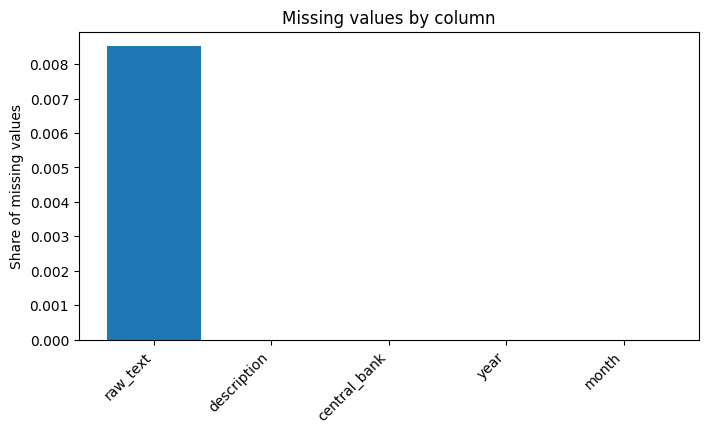

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(missing_values.index, missing_values["missing_share"])
plt.ylabel("Share of missing values")
plt.title("Missing values by column")
plt.xticks(rotation=45, ha="right")
plt.show()

Some observations have missing text. These entries can still contain metadata, such as the year, month, bank or description, but they cannot be used directly for topic modeling because the NLP models require textual content. Therefore, observations with missing speech text will be removed before modeling.

In [ ]:
#Text Availability
df["has_text"] = df["raw_text"].notna()

text_availability = df["has_text"].value_counts().rename(index={True: "Available text", False: "Missing text"})
text_availability

,count
has_text,
Available text,19211
Missing text,165


In [ ]:
df.loc[df["raw_text"].isna(), ["description", "central_bank", "year", "month"]].head(10)

,description,central_bank,year,month
2,"Address by Mr Nicholas C Garganas, Deputy Gove...",bank of greece,2000,3
139,"Speech by Mr Yannis Stournaras, Governor of th...",bank of greece,2020,12
180,"Inaugural address by Dr Chiranjibi Nepal, Gove...",central bank of nepal,2017,8
385,"Keynote speech (digitally) by Mr Klaas Knot, P...",netherlands bank,2023,2
427,"Speech by Mr Klaas Knot, President of the Neth...",netherlands bank,2024,10
433,"Text of the first Klaas Knot Lecture, by Mr Kl...",netherlands bank,2025,2
853,"Speech by Ms Michele Bullock, Assistant Govern...",reserve bank of australia,2018,11
854,"Remarks by Mr Guy Debelle, Deputy Governor of ...",reserve bank of australia,2018,11
869,"Speech by Mr Guy Debelle, Deputy Governor of t...",reserve bank of australia,2019,4
889,"Article by Philip Lowe, Chair of the CGFS and ...",reserve bank of australia,2019,10


A small share of observations contains no speech text. Looking at these examples confirms that the metadata can be available even when the full text is missing. Since the project focuses on textual analysis, these observations will be excluded from the modeling corpus.

In [ ]:
# Some texts may not be missing but can still be empty strings.
df["raw_text_stripped"] = df["raw_text"].fillna("").astype(str).str.strip()

n_empty_texts = (df["raw_text_stripped"] == "").sum()
n_valid_texts = (df["raw_text_stripped"] != "").sum()

print("Empty or missing texts:", n_empty_texts)
print("Valid non-empty texts:", n_valid_texts)
print(f"Share of empty or missing texts: {n_empty_texts / len(df):.2%}")

Empty or missing texts: 191
Valid non-empty texts: 19185
Share of empty or missing texts: 0.99%


##7.Temporal Coverage

In [ ]:
print("Minimum year:", df["year"].min())
print("Maximum year:", df["year"].max())
print("Number of distinct years:", df["year"].nunique())

Minimum year: 1997
Maximum year: 2025
Number of distinct years: 29


In [ ]:
#Nombre de discours par annees
speeches_by_year = (
    df.groupby("year")
      .size()
      .reset_index(name="n_speeches")
      .sort_values("year")
)

speeches_by_year.head()

,year,n_speeches
0,1997,198
1,1998,202
2,1999,274
3,2000,291
4,2001,297


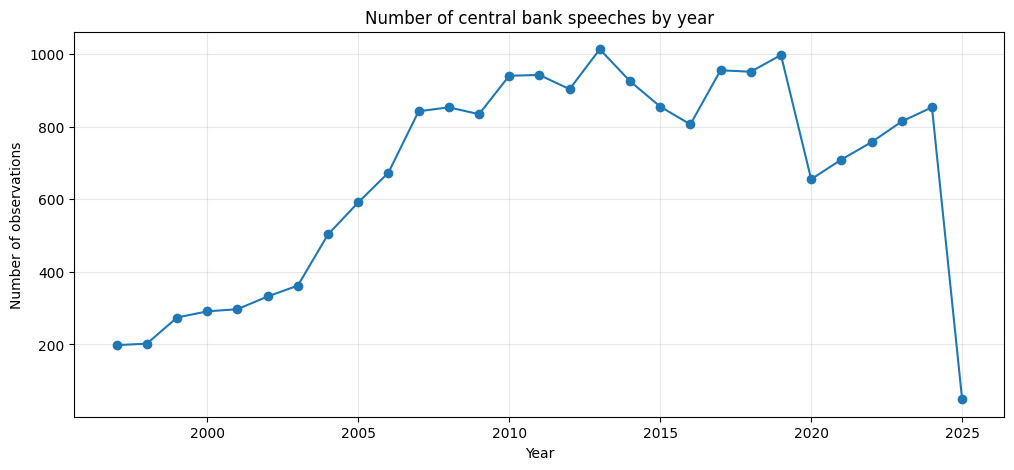

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(speeches_by_year["year"], speeches_by_year["n_speeches"], marker="o")
plt.xlabel("Year")
plt.ylabel("Number of observations")
plt.title("Number of central bank speeches by year")
plt.grid(alpha=0.3)
plt.show()

The dataset covers several decades of central bank communication. However, the number of observations is not constant over time. This matters for the interpretation of temporal trends: an increase in the frequency of a topic can reflect a genuine change in communication, but it can also be affected by the number of speeches available in a given year.

In [ ]:
#Monthly Distribution

speeches_by_month = (
    df.groupby("month")
      .size()
      .reset_index(name="n_speeches")
      .sort_values("month")
)

speeches_by_month

,month,n_speeches
0,1,1130
1,2,1448
2,3,1704
3,4,1548
4,5,1752
5,6,1747
6,7,1366
7,8,1022
8,9,1587
9,10,2124


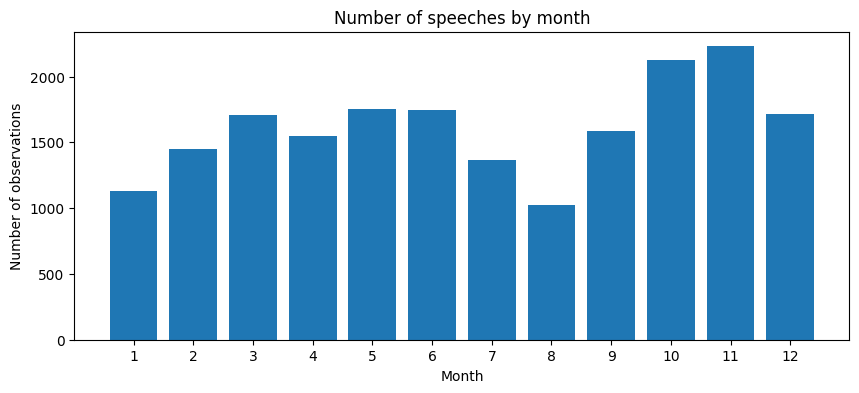

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(speeches_by_month["month"], speeches_by_month["n_speeches"])
plt.xlabel("Month")
plt.ylabel("Number of observations")
plt.title("Number of speeches by month")
plt.xticks(range(1, 13))
plt.show()

## 8. Central Bank coverage
I want to see if there is any country/banks that dominates the corpus

In [ ]:
bank_counts = (
    df["central_bank"]
    .value_counts()
    .reset_index()
)

bank_counts.columns = ["central_bank", "n_speeches"]
bank_counts.head(20)

,central_bank,n_speeches
0,european central bank,2516
1,board of governors of the federal reserve system,1775
2,reserve bank of india,934
3,deutsche bundesbank,866
4,bank of england,777
5,bank of japan,773
6,bank of canada,588
7,reserve bank of australia,560
8,central bank of the philippines,549
9,central bank of malaysia,541


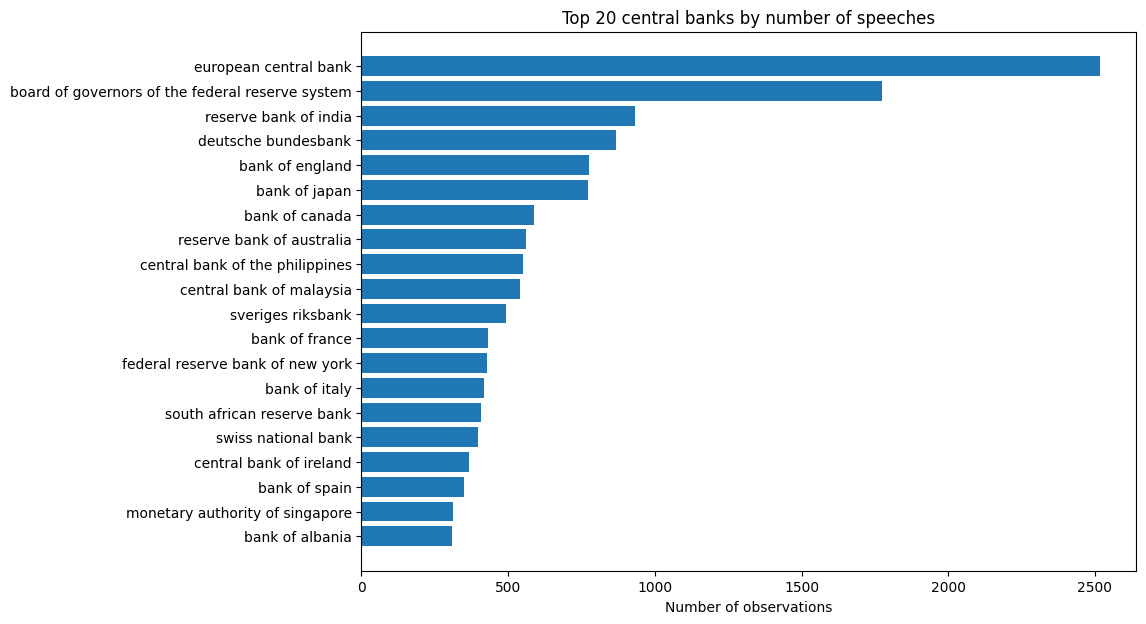

In [ ]:
top_banks = bank_counts.head(20)

plt.figure(figsize=(10, 7))
plt.barh(top_banks["central_bank"][::-1], top_banks["n_speeches"][::-1])
plt.xlabel("Number of observations")
plt.title("Top 20 central banks by number of speeches")
plt.show()

In [ ]:
top_10_share = bank_counts.head(10)["n_speeches"].sum() / bank_counts["n_speeches"].sum()
top_20_share = bank_counts.head(20)["n_speeches"].sum() / bank_counts["n_speeches"].sum()

print(f"Share of speeches from top 10 central banks: {top_10_share:.2%}")
print(f"Share of speeches from top 20 central banks: {top_20_share:.2%}")
print("Number of distinct central banks:", df["central_bank"].nunique())




'''Le corpus est déséquilibré. Les 10 banques centrales les plus présentes représentent environ 51% des discours. Les 20 premières représentent environ 71% du corpus.
Donc les topics extraits risquent de refléter davantage le vocabulaire des banques centrales les plus représentées, notamment la BCE, la Fed,
la Banque d’Inde, la Bundesbank, la Banque d’Angleterre, etc. '''

Share of speeches from top 10 central banks: 50.99%
Share of speeches from top 20 central banks: 71.21%
Number of distinct central banks: 118


The corpus is not necessarily balanced across central banks. Some institutions contribute many more speeches than others. This imbalance is important because the topics extracted by unsupervised models may partly reflect the vocabulary of the most represented central banks.

## 9.Text Lenght Analysis

In [ ]:
def count_words(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())

def count_characters(text):
    if pd.isna(text):
        return 0
    return len(str(text))

df["n_words"] = df["raw_text"].apply(count_words)
df["n_characters"] = df["raw_text"].apply(count_characters)

df[["n_words", "n_characters"]].describe()

''' Un discours moyen contient environ 2 718 mots, et le discours médian environ 2 389 mots. Cela veut dire que les documents sont assez longs,
ce qui est favorable au topic modeling. Mais il y a aussi :0 '''

,n_words,n_characters
count,19376.000000,19376.000000
mean,2718.361014,17319.522244
std,1785.698905,11401.235463
min,0.000000,0.000000
25%,1462.000000,9413.750000
50%,2389.000000,15219.000000
75%,3589.000000,22794.000000
max,48814.000000,340677.000000


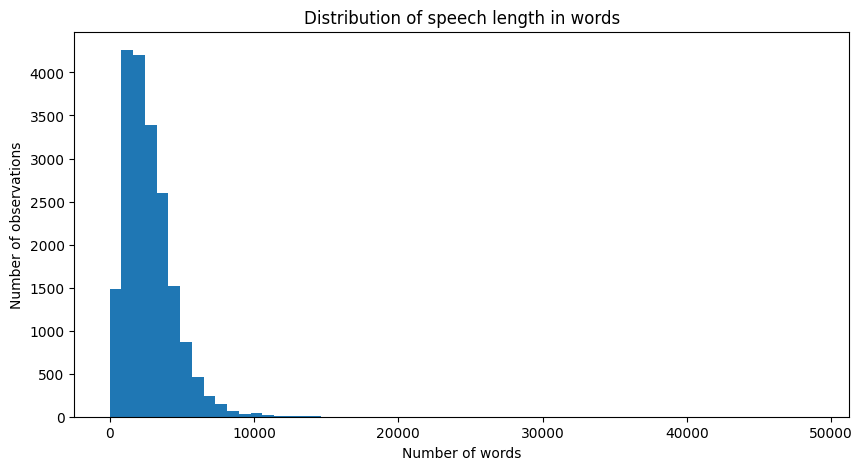

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df["n_words"], bins=60)
plt.xlabel("Number of words")
plt.ylabel("Number of observations")
plt.title("Distribution of speech length in words")
plt.show()

#Speech lengths are highly heterogeneous. Most speeches contain a few thousand words, but the corpus also includes empty or very short entries
#and a few extremely long speeches. This motivates filtering very short documents and normalizing tone scores by document length.

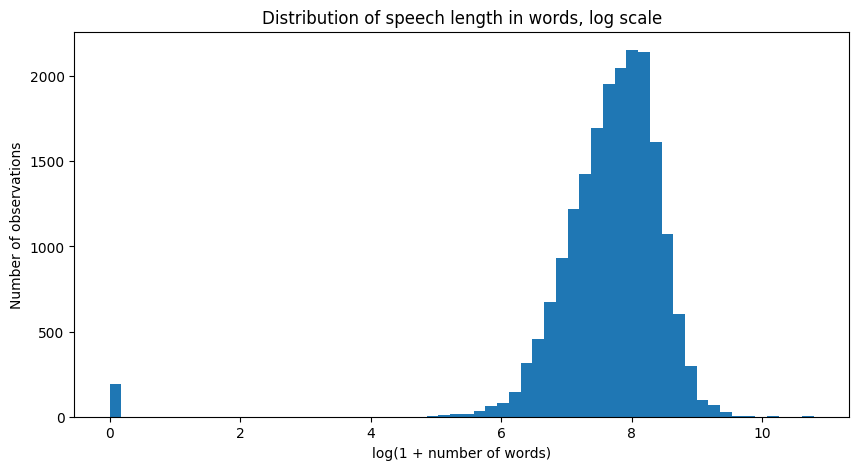

In [ ]:
#log vis
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(df["n_words"]), bins=60)
plt.xlabel("log(1 + number of words)")
plt.ylabel("Number of observations")
plt.title("Distribution of speech length in words, log scale")
plt.show()

## 10.Short documents analysis

On identifie les textes qui risquent de poser problème.

In [ ]:
thresholds = [0, 50, 100, 200, 500]

short_doc_summary = []

for threshold in thresholds:
    n_docs = (df["n_words"] < threshold).sum()
    share_docs = n_docs / len(df)
    short_doc_summary.append({
        "threshold_words": threshold,
        "n_documents_below_threshold": n_docs,
        "share": share_docs
    })

short_doc_summary = pd.DataFrame(short_doc_summary)
short_doc_summary

#Très peu de documents sont courts. Moins de 1.1% des documents ont moins de 200 mots

,threshold_words,n_documents_below_threshold,share
0,0,0,0.000000
1,50,192,0.009909
2,100,195,0.010064
3,200,210,0.010838
4,500,479,0.024721


In [ ]:
df.loc[df["n_words"] < 50, ["description", "raw_text", "central_bank", "year", "month", "n_words"]].head(10)

,description,raw_text,central_bank,year,month,n_words
2,"Address by Mr Nicholas C Garganas, Deputy Gove...",None,bank of greece,2000,3,0
139,"Speech by Mr Yannis Stournaras, Governor of th...",None,bank of greece,2020,12,0
180,"Inaugural address by Dr Chiranjibi Nepal, Gove...",None,central bank of nepal,2017,8,0
385,"Keynote speech (digitally) by Mr Klaas Knot, P...",None,netherlands bank,2023,2,0
427,"Speech by Mr Klaas Knot, President of the Neth...",None,netherlands bank,2024,10,0
433,"Text of the first Klaas Knot Lecture, by Mr Kl...",None,netherlands bank,2025,2,0
853,"Speech by Ms Michele Bullock, Assistant Govern...",None,reserve bank of australia,2018,11,0
854,"Remarks by Mr Guy Debelle, Deputy Governor of ...",None,reserve bank of australia,2018,11,0
869,"Speech by Mr Guy Debelle, Deputy Governor of t...",None,reserve bank of australia,2019,4,0
889,"Article by Philip Lowe, Chair of the CGFS and ...",None,reserve bank of australia,2019,10,0


I inspect short documents because they can be problematic for topic modeling. A speech with only a few words does not provide enough context to estimate a meaningful topic distribution. In the preprocessing stage, I will remove documents below a minimum length threshold.

## 11.Average speech length over time

In [ ]:
#Cette figure est utile pour éviter une mauvaise interprétation des trends.

length_by_year = (
    df.groupby("year")["n_words"]
      .agg(["mean", "median", "count"])
      .reset_index()
      .rename(columns={
          "mean": "mean_words",
          "median": "median_words",
          "count": "n_observations"
      })
)

length_by_year.head()

,year,mean_words,median_words,n_observations
0,1997,3173.151515,2997.0,198
1,1998,3215.900990,3031.5,202
2,1999,3152.894161,2923.5,274
3,2000,3105.326460,2920.0,291
4,2001,3208.875421,3100.0,297


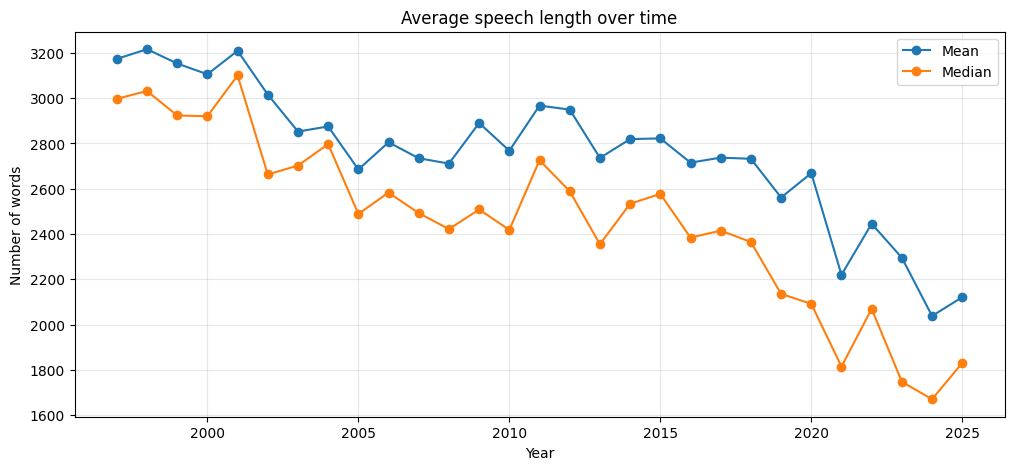

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(length_by_year["year"], length_by_year["mean_words"], marker="o", label="Mean")
plt.plot(length_by_year["year"], length_by_year["median_words"], marker="o", label="Median")
plt.xlabel("Year")
plt.ylabel("Number of words")
plt.title("Average speech length over time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

''' Si la moyenne est beaucoup plus haute que la médiane, cela indique que certaines années contiennent quelques discours très longs. La médiane est souvent plus robuste.

Pourquoi c’est important : Pour le score hawkish/dovish,on ne dois jamais utiliser le nombre brut de mots hawkish ou dovish.
Un discours long aura mécaniquement plus de mots hawkish/dovish. Il faut donc normaliser :
hawkish_score = hawkish_terms / total_words
dovish_score = dovish_terms / total_words'''

The average and median length of speeches vary over time. This is relevant for the later hawkish/dovish analysis, because raw counts of hawkish or dovish terms would mechanically increase with document length. For this reason, the tone scores will be normalized by the number of words.

## 11. Duplicate Text

In [ ]:
n_duplicates = df.duplicated(subset=["raw_text"]).sum()
duplicate_share = n_duplicates / len(df)

print("Number of exact duplicate texts:", n_duplicates)
print(f"Share of exact duplicate texts: {duplicate_share:.2%}")

Number of exact duplicate texts: 204
Share of exact duplicate texts: 1.05%


In [ ]:
duplicates_preview = (
    df[df.duplicated(subset=["raw_text"], keep=False)]
    .sort_values("raw_text")
    [["description", "central_bank", "year", "month", "n_words", "raw_text"]]
)

duplicates_preview.head(10)

,description,central_bank,year,month,n_words,raw_text
912,"Address by Ms Michele Bullock, Assistant Gover...",reserve bank of australia,2020,11,0,
10521,"Introductory remarks by Prof Claudia Buch, Vic...",deutsche bundesbank,2021,11,0,
11462,"Speech by Sir David Ramsden, Deputy Governor f...",bank of england,2022,2,0,
11463,"Speech by Sir Jon Cunliffe, Deputy Governor fo...",bank of england,2022,3,0,
11518,"Speech by Mr Ben Broadbent, Deputy Governor fo...",bank of england,2023,8,0,
11526,"Speech (virtual) by Sir David Ramsden, Deputy ...",bank of england,2023,11,0,
13395,"Remarks by Mr Vítor Constâncio, Vice-President...",european central bank,2017,5,0,
13918,"Speech by Ms Isabel Schnabel, Member of the Ex...",european central bank,2021,7,0,
13968,"Contribution by Mr Fabio Panetta, Member of th...",european central bank,2022,2,0,
10480,"Speech by Dr Jens Weidmann, President of the D...",deutsche bundesbank,2020,10,0,


Exact duplicate texts can bias topic modeling because repeated documents give excessive weight to the same vocabulary. Therefore, exact duplicates will be removed before fitting the models.

In [ ]:
#si raw text none, tous les none peuvent compter comme doublons donc corrections
#Quand raw_text vaut None ou "", pandas peut compter ces valeurs comme des doublons. Donc beaucoup de “doublons” sont juste des textes manquants ou vides
#40 vrais doublons parmi les textes non manquants, soit 0.21%.
#Il y a très peu de doublons réels. On les supprimera quand même avant les modèles, car même 40 répétitions peuvent légèrement biaiser les topics.

n_duplicates_non_missing = df[df["raw_text"].notna()].duplicated(subset=["raw_text"]).sum()
duplicate_non_missing_share = n_duplicates_non_missing / df["raw_text"].notna().sum()

print("Number of exact duplicate non-missing texts:", n_duplicates_non_missing)
print(f"Share among non-missing texts: {duplicate_non_missing_share:.2%}")

Number of exact duplicate non-missing texts: 40
Share among non-missing texts: 0.21%


## 12. Macro Final Periods

In [ ]:
# macro_period_definitions = pd.DataFrame({
#     "macro_period": [
#         "Pre-GFC",
#         "Global Financial Crisis",
#         "Euro crisis / post-GFC",
#         "Low rates / QE",
#         "Covid",
#         "Inflation tightening"
#     ],
#     "years": [
#         "1997–2006",
#         "2007–2009",
#         "2010–2014",
#         "2015–2019",
#         "2020–2021",
#         "2022–2025"
#     ],
#     "interpretation": [
#         "Pre-crisis macro-financial environment",
#         "Global financial crisis and liquidity stress",
#         "Post-crisis regulation and euro area sovereign stress",
#         "Low interest rates, QE and unconventional policy",
#         "Covid shock and emergency monetary policy response",
#         "Inflation shock and monetary tightening"
#     ]
# })

# macro_period_definitions

In [ ]:
def assign_macro_period(year):
    if pd.isna(year):
        return "Unknown"
    year = int(year)
    if year <= 2006:
        return "Pre-GFC"
    elif 2007 <= year <= 2009:
        return "Global Financial Crisis"
    elif 2010 <= year <= 2014:
        return "Euro crisis / post-GFC"
    elif 2015 <= year <= 2019:
        return "Low rates / QE"
    elif 2020 <= year <= 2021:
        return "Covid"
    elif year >= 2022:
        return "Inflation tightening"
    else:
        return "Unknown"

df["macro_period"] = df["year"].apply(assign_macro_period)

df["macro_period"].value_counts()

,count
macro_period,
Euro crisis / post-GFC,4723
Low rates / QE,4564
Pre-GFC,3723
Global Financial Crisis,2529
Inflation tightening,2473
Covid,1364


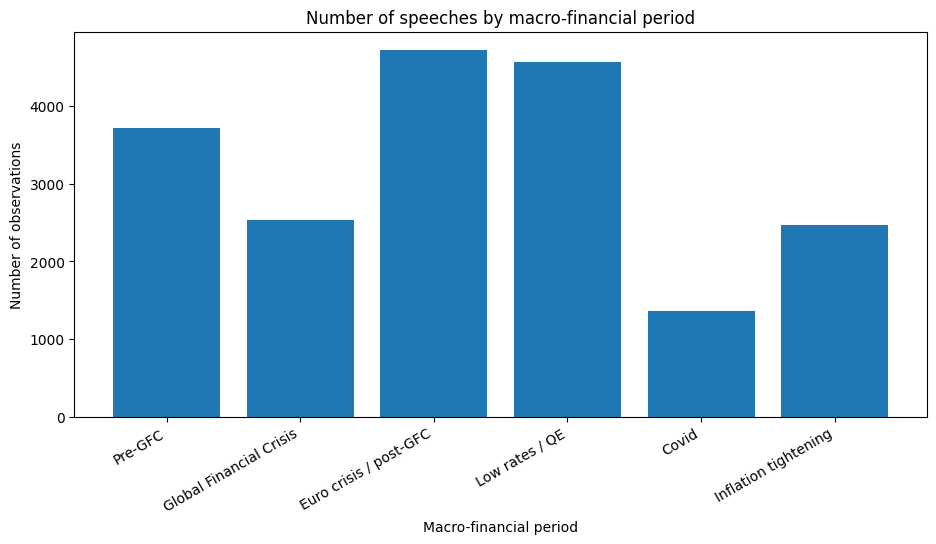

In [ ]:
period_order = [
    "Pre-GFC",
    "Global Financial Crisis",
    "Euro crisis / post-GFC",
    "Low rates / QE",
    "Covid",
    "Inflation tightening",
    "Unknown"
]

period_counts = (
    df["macro_period"]
    .value_counts()
    .reindex(period_order)
    .dropna()
    .reset_index()
)

period_counts.columns = ["macro_period", "n_observations"]

plt.figure(figsize=(11, 5))
plt.bar(period_counts["macro_period"], period_counts["n_observations"])
plt.xlabel("Macro-financial period")
plt.ylabel("Number of observations")
plt.title("Number of speeches by macro-financial period")
plt.xticks(rotation=30, ha="right")
plt.show()

I define broad macro-financial periods to facilitate the interpretation of topic dynamics. These periods are not used as supervised labels, but they help relate changes in central bank communication to major macroeconomic regimes such as the global financial crisis, the Covid period, and the recent inflation tightening cycle.

## 13.First lexical inspection

Avant de nettoyer, on regarde les mots fréquents.

In [ ]:
# I use a simple tokenizer only for exploratory analysis.
# A more systematic preprocessing function will be defined later for the models.

basic_stopwords = {
    "the", "and", "for", "that", "with", "this", "are", "was", "were", "from",
    "have", "has", "had", "not", "but", "they", "their", "there", "which",
    "will", "would", "could", "should", "can", "may", "also", "one", "two",
    "more", "our", "you", "your", "his", "her", "its", "about", "into",
    "than", "then", "such", "these", "those"
}

domain_stopwords = {
    "central", "bank", "banks", "speech", "speeches", "mr", "mrs", "dr"
}
#Ce sont des mots spécifiques au corpus mais trop génériques.comme tous les textes parlent de banques centrales, le mot bank serait partout. Il n’aide pas à distinguer les thèmes.

stopwords = basic_stopwords.union(domain_stopwords)


''' FCT:
met le texte en minuscules ;
enlève les caractères qui ne sont pas des lettres ;
découpe le texte en mots ;
supprime les mots trop courts ;
supprime les stopwords.
'''
def simple_tokenize(text):

    if pd.isna(text):
        return []
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [tok for tok in tokens if len(tok) > 2 and tok not in stopwords]
    return tokens

all_tokens = []

for text in tqdm(df.loc[df["raw_text"].notna(), "raw_text"].sample(
    min(3000, df["raw_text"].notna().sum()),
    random_state=RANDOM_STATE
)):
    all_tokens.extend(simple_tokenize(text))

word_counts = Counter(all_tokens)
top_words = pd.DataFrame(word_counts.most_common(30), columns=["word", "count"])
top_words

  0%|          | 0/3000 [00:00<?, ?it/s]

,word,count
0,financial,50187
1,policy,33225
2,monetary,25436
3,inflation,23485
4,economic,23002
5,been,22682
6,market,22442
7,growth,21367
8,rate,19408
9,economy,19161


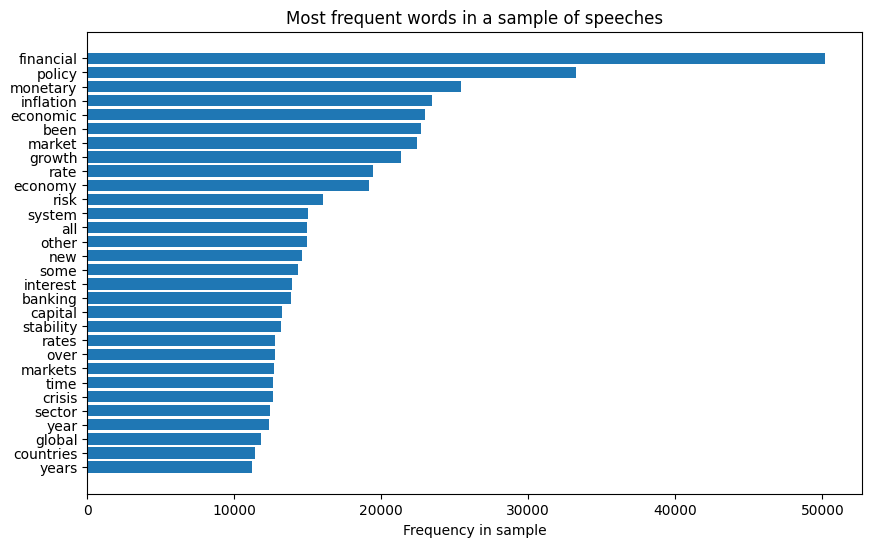

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(top_words["word"][::-1], top_words["count"][::-1])
plt.xlabel("Frequency in sample")
plt.title("Most frequent words in a sample of speeches")
plt.show()

This first lexical inspection gives a preliminary view of the vocabulary of the corpus. It also helps identify very frequent domain-specific terms that may dominate topic models without being informative, such as generic references to central banks or speeches.

## 14. Final EDA Summary Table

In [ ]:
eda_summary = {
    "number_of_observations": len(df),
    "number_of_columns": df.shape[1],
    "number_of_non_missing_texts": int(df["raw_text"].notna().sum()),
    "share_of_missing_texts": float(df["raw_text"].isna().mean()),
    "number_of_distinct_central_banks": int(df["central_bank"].nunique()),
    "min_year": int(df["year"].min()),
    "max_year": int(df["year"].max()),
    "mean_words_per_observation": float(df["n_words"].mean()),
    "median_words_per_observation": float(df["n_words"].median()),
    "exact_duplicate_non_missing_texts": int(n_duplicates_non_missing)
}

eda_summary_df = pd.DataFrame([eda_summary]).T
eda_summary_df.columns = ["value"]
eda_summary_df

,value
number_of_observations,19376.000000
number_of_columns,9.000000
number_of_non_missing_texts,19211.000000
share_of_missing_texts,0.008516
number_of_distinct_central_banks,118.000000
min_year,1997.000000
max_year,2025.000000
mean_words_per_observation,2718.361014
median_words_per_observation,2389.000000
exact_duplicate_non_missing_texts,40.000000


The exploratory analysis shows that the corpus is large enough for topic modeling, but also highlights important preprocessing decisions. In particular, I need to remove missing texts, remove exact duplicates, and filter very short documents. The dataset is also imbalanced across years and central banks, which will be considered when interpreting topic prevalence over time.